# Descrição geral
Os dados foram sintetisados usando um script simples, aqui o foco é gerar um conjunto mais simples, mais rapido e mais facil de usar no treinamento

In [25]:
import pandas as pd
from seeds.seed_perfil_usuario_kmeans import gerar_tabela
df_perfil_usuario = gerar_tabela(numero_linhas_iguais=6000, numero_linhas_abaixo=2000, numero_linhas_acima=2000)

In [26]:
print('Trechos')
display(df_perfil_usuario.head())

print('Shape')
print(df_perfil_usuario.shape)

print('Potenciais falhas')
print(df_perfil_usuario.isnull().sum())

Trechos


,ALIMENTACAO,TRANSPORTE,SAUDE,MORADIA,EDUCACAO,LAZER,SERVICOS,ASSINATURAS,DIVIDAS,POUPANCA
0,12.10,3.76,1.74,8.76,3.10,28.88,0.77,4.82,0.43,2.12
1,26.18,0.17,1.78,1.77,28.32,19.64,12.68,0.05,0.77,8.64
2,0.98,32.50,19.97,5.02,6.16,5.51,20.85,0.44,5.88,2.69
3,0.55,3.04,4.01,5.57,7.16,16.91,35.45,11.44,7.60,8.27
4,4.08,25.71,2.01,0.19,8.11,5.12,17.32,0.48,4.38,36.16


Shape
(10000, 10)
Potenciais falhas
ALIMENTACAO    0
TRANSPORTE     0
SAUDE          0
MORADIA        0
EDUCACAO       0
LAZER          0
SERVICOS       0
ASSINATURAS    0
DIVIDAS        0
POUPANCA       0
dtype: int64


# Normalizando valores

In [27]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import joblib

scaler = StandardScaler()

# fit + transform: aprende a média/desvio e aplica
# X_normalizado = scaler.fit_transform(df_perfil_usuario)
X_normalizado = df_perfil_usuario



# X_normalizado é um numpy array, média 0 e desvio 1 em cada coluna
print("Média após normalização:", X_normalizado.mean(axis=0).round(2))
print("Desvio após normalização:", X_normalizado.std(axis=0).round(2))

df_normalizado = pd.DataFrame(X_normalizado, columns=df_perfil_usuario.columns.to_list())

display(df_normalizado.head())

# ============================================
# 4. SALVAR O SCALER (obrigatório para produção)
# ============================================

# joblib.dump(scaler, "scaler_perfil.pkl")
# print("Scaler salvo em: scaler_perfil.pkl")

Média após normalização: ALIMENTACAO    9.93
TRANSPORTE     9.74
SAUDE          9.76
MORADIA        9.70
EDUCACAO       9.97
LAZER          9.79
SERVICOS       9.77
ASSINATURAS    9.79
DIVIDAS        9.79
POUPANCA       9.79
dtype: float64
Desvio após normalização: ALIMENTACAO    9.13
TRANSPORTE     8.94
SAUDE          8.99
MORADIA        8.93
EDUCACAO       9.17
LAZER          8.99
SERVICOS       8.84
ASSINATURAS    9.11
DIVIDAS        9.05
POUPANCA       9.01
dtype: float64


,ALIMENTACAO,TRANSPORTE,SAUDE,MORADIA,EDUCACAO,LAZER,SERVICOS,ASSINATURAS,DIVIDAS,POUPANCA
0,12.10,3.76,1.74,8.76,3.10,28.88,0.77,4.82,0.43,2.12
1,26.18,0.17,1.78,1.77,28.32,19.64,12.68,0.05,0.77,8.64
2,0.98,32.50,19.97,5.02,6.16,5.51,20.85,0.44,5.88,2.69
3,0.55,3.04,4.01,5.57,7.16,16.91,35.45,11.44,7.60,8.27
4,4.08,25.71,2.01,0.19,8.11,5.12,17.32,0.48,4.38,36.16


# Escolher quantidade de grupos

A quantidade de grupos já foi escolhida no primeiro treino, a celula vai continuar no codigo para mostrar que o valor escolhido não foi aleatorio

Grupos: 2 | Inércia: 7516735.00
Grupos: 3 | Inércia: 7000915.89
Grupos: 4 | Inércia: 6501615.70
Grupos: 5 | Inércia: 6028986.12
Grupos: 6 | Inércia: 5608560.42
Grupos: 7 | Inércia: 5207648.02
Grupos: 8 | Inércia: 4824918.11
Grupos: 9 | Inércia: 4463327.23
Grupos: 10 | Inércia: 4118352.51
Grupos: 11 | Inércia: 4034546.52
Grupos: 12 | Inércia: 3982323.87
Grupos: 13 | Inércia: 3928849.37
Grupos: 14 | Inércia: 3883323.09
Grupos: 15 | Inércia: 3834615.66
Grupos: 16 | Inércia: 3781277.68
Grupos: 17 | Inércia: 3737626.34
Grupos: 18 | Inércia: 3703073.56
Grupos: 19 | Inércia: 3653320.37


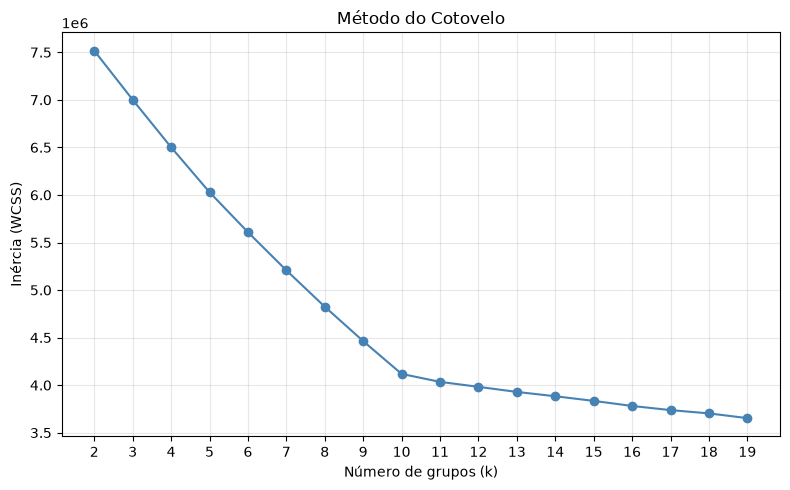

In [28]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inercias = []
grupos_teste = range(2, 20)

for k in grupos_teste:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_normalizado)
    inercias.append(kmeans.inertia_)
    print(f"Grupos: {k} | Inércia: {kmeans.inertia_:.2f}")

# ============================================
# PLOTAR O GRÁFICO
# ============================================

plt.figure(figsize=(8, 5))
plt.plot(grupos_teste, inercias, marker='o', linestyle='-', color='steelblue')
plt.title('Método do Cotovelo')
plt.xlabel('Número de grupos (k)')
plt.ylabel('Inércia (WCSS)')
plt.xticks(grupos_teste)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Treino do modelo
aqui é onde o filho chora e a mãe não vê

In [ ]:
from sklearn.cluster import KMeans
import pandas as pd


kmeans = KMeans(n_clusters=12, random_state=42, n_init=10)
kmeans.fit(X_normalizado)

print(f"Modelo treinado com {kmeans.n_clusters} grupos")
print(f"Inércia final: {kmeans.inertia_:.2f}")

# Desnormalizar os centros para ler em percentuais
centros = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=df_normalizado.columns.to_list()
)

display(centros)

# print("\n" + "="*70)
# print("CENTROS DOS PERFIS (valores em %)")
# print("="*70)
# print(centros.round(2))


Modelo treinado com 12 grupos
Inércia final: 3982323.87


,ALIMENTACAO,TRANSPORTE,SAUDE,MORADIA,EDUCACAO,LAZER,SERVICOS,ASSINATURAS,DIVIDAS,POUPANCA
0,7.405654,7.234089,7.796201,7.837084,8.152749,8.035955,7.362469,29.533073,8.268570,7.685911
1,8.061429,7.278839,7.733806,7.749754,8.118404,7.653940,8.018493,7.579386,7.152634,30.395145
2,7.405182,7.302477,7.792989,7.397148,7.865375,7.875920,8.018955,7.771420,29.809852,8.180193
3,7.695088,7.586910,30.696322,7.703173,7.850740,7.457873,7.881951,7.601504,7.679495,7.518625
4,7.523719,7.682312,7.691049,30.680405,8.153433,7.531335,7.726698,7.544803,7.200060,7.549952
5,7.702968,7.989668,7.536689,7.278472,29.917165,7.712248,7.183333,7.823444,7.896755,7.930698
6,9.524159,5.945874,8.995852,10.119663,7.754419,8.601151,9.988979,8.134300,8.654093,8.295461
7,31.365634,7.218085,7.949913,7.346206,7.025572,8.218047,7.429577,7.384527,7.979801,7.531095
8,7.542743,7.331003,7.670363,7.709498,8.274557,29.798698,7.279872,8.035880,7.948324,7.773799
9,7.663899,7.413923,7.083317,7.434530,7.998626,8.388490,30.991040,7.653057,7.290136,7.894332


In [ ]:
rotulos = kmeans.labels_
contagem = pd.Series(rotulos).value_counts().sort_index()
print("\n" + "="*70)
print("USUÁRIOS POR PERFIL")
print("="*70)
print(contagem)



USUÁRIOS POR PERFIL
0     953
1    1020
2    1010
3    1006
4     921
5    1011
6    1014
7     988
8    1014
9    1063
Name: count, dtype: int64


# Metogologia 

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- TOTAL
- TOTAL_GASTOS
Feature names seen at fit time, yet now missing:
- ALIMENTACAO
- ASSINATURAS
- DIVIDAS
- EDUCACAO
- LAZER
- ...


# Exportar modelo


In [ ]:
import joblib

joblib.dump(kmeans, "modelo_kmeans_perfil.pkl")
joblib.dump(scaler, "scaler_perfil.pkl")